# Project Overview

This notebook explores the relationship between macroeconomic conditions and retail sales across European countries between 2016 and 2025.

The analysis compares:

- GDP as an indicator of economic conditions.
- Retail sales across total retail, essential retail, and discretionary retail sectors.

The aim is to investigate whether different retail sectors respond differently to economic conditions and whether the observed patterns are consistent with the "lipstick effect" hypothesis.

In [99]:
# =============================
# Load the data
# ============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('../Data/Processed/final_dataset.csv')



In [100]:
# =============================
# Create sector labels (IMPORTANT)
# =============================
df["sector_type"] = df["indicator"].map({
    "G47": "Total retail",
    "G47_NF_HLTH": "Essential-ish",
    "G476": "Discretionary"
})

In [101]:
# =============================
# Dataset Overview
# =============================

# Check structure
print(df.info())

# number of countries
print("Countries:", df["country"].nunique())

# indicator categories
print("Indicators:", df['indicator'].unique())

# year range
print("Years:", df['year'].min(), "-", df['year'].max())

# rows and columns
print("Shape:", df.shape)

# check if indicators are balanced
print(df.groupby("indicator").size())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      691 non-null    object 
 1   year         691 non-null    int64  
 2   indicator    691 non-null    object 
 3   sales_value  691 non-null    float64
 4   gdp          691 non-null    float64
 5   gdp_unit     691 non-null    object 
 6   sector_type  691 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 37.9+ KB
None
Countries: 36
Indicators: ['G47' 'G476' 'G47_NF_HLTH']
Years: 2016 - 2025
Shape: (691, 7)
indicator
G47            352
G476           167
G47_NF_HLTH    172
dtype: int64


- The dataset contains a multi-country panel structure
- Covers 3 retail sectors across 40 European countries
- Time range: 2016–2025
- Balanced structure across indicators (no severe missing sectors)

In [102]:
# ============================
# numeric summary block
# ============================

def numeric_summary(df, col):
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n=== {col} Summary ===")
    print(f"Q1: {q1:.2f}")
    print(f"Median: {q2:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Outlier bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

    if len(outliers) > 0:
        print("\nTop outliers:")
        print(outliers[[col, "country", "year"]].sort_values(col, ascending=False).head())

    # simple interpretation hint
    if len(outliers)/len(df) > 0.05:
        print("High outlier presence → distribution likely skewed or heterogeneous")
    else:
        print("Relatively stable distribution")

# Example usage:
numeric_summary(df, "sales_value")
numeric_summary(df, "gdp")


=== sales_value Summary ===
Q1: 68.53
Median: 76.22
Q3: 87.44
IQR: 18.91
Outlier bounds: [40.17, 115.81]
Number of outliers: 25 (3.62%)

Top outliers:
     sales_value country  year
676   330.966667      TR  2023
678   330.666667      TR  2023
682   305.625000      TR  2025
681   299.775000      TR  2025
680   242.425000      TR  2024
Relatively stable distribution

=== gdp Summary ===
Q1: 55707.90
Median: 279489.50
Q3: 579927.05
IQR: 524219.15
Outlier bounds: [-730620.83, 1366255.78]
Number of outliers: 87 (12.59%)

Top outliers:
           gdp country  year
168  3094378.2      DE  2022
169  3094378.2      DE  2022
170  3067468.0      DE  2023
171  3067468.0      DE  2023
174  3058985.5      DE  2025
High outlier presence → distribution likely skewed or heterogeneous


In [103]:
# check for missing values
print("Missing values:\n", df.isnull().sum())
# No missing values were present after cleaning.

Missing values:
 country        0
year           0
indicator      0
sales_value    0
gdp            0
gdp_unit       0
sector_type    0
dtype: int64


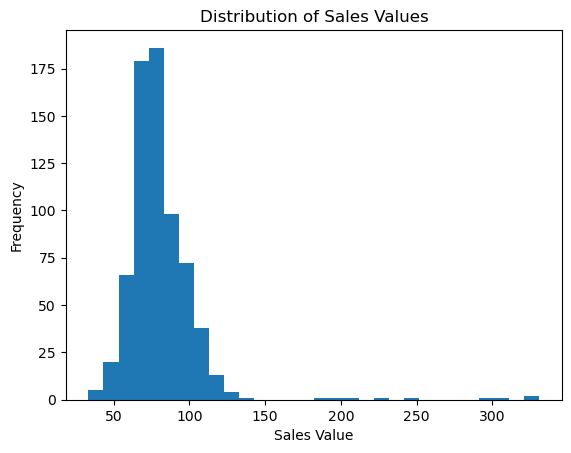

Skewness: 5.053601426552912
Kurtosis: 39.398869268726905


,count,mean,std,min,25%,50%,75%,max
year,691.0,2020.250362,2.817566,2016.0,2018.00000,2020.00,2023.000000,2.025000e+03
sales_value,691.0,80.820302,26.590064,33.3,68.53125,76.22,87.441667,3.309667e+02
gdp,691.0,555535.065557,734114.742565,3388.1,55707.90000,279489.50,579927.050000,3.094378e+06


In [104]:
# distribution of sales values
plt.hist(df['sales_value'], bins=30)
plt.title('Distribution of Sales Values')
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.show()


print("Skewness:", df["sales_value"].skew())
print("Kurtosis:", df["sales_value"].kurtosis())
df.describe().T

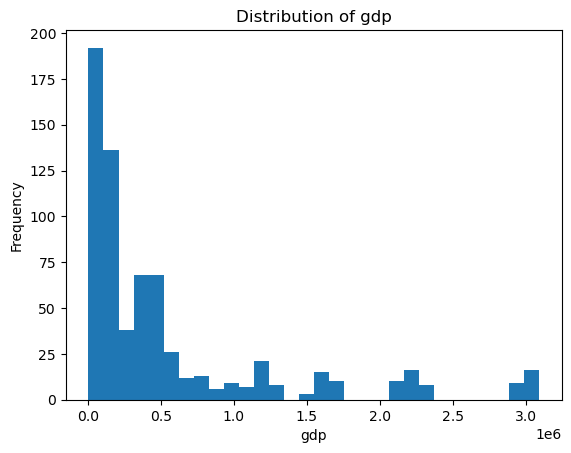

Skewness: 1.9683626786675075
Kurtosis: 3.1951206205440497


,count,mean,std,min,25%,50%,75%,max
year,691.0,2020.250362,2.817566,2016.0,2018.00000,2020.00,2023.000000,2.025000e+03
sales_value,691.0,80.820302,26.590064,33.3,68.53125,76.22,87.441667,3.309667e+02
gdp,691.0,555535.065557,734114.742565,3388.1,55707.90000,279489.50,579927.050000,3.094378e+06


In [105]:
# distribution of gdp
plt.hist(df['gdp'], bins=30)
plt.title('Distribution of gdp')
plt.xlabel('gdp')
plt.ylabel('Frequency')
plt.show()


print("Skewness:", df["gdp"].skew())
print("Kurtosis:", df["gdp"].kurtosis())
df.describe().T

Both GDP and sales distributions are heavily right-skewed, indicating:
- Strong inequality across countries
- A small number of high-income economies dominate scale

This motivates log transformation for interpretability.

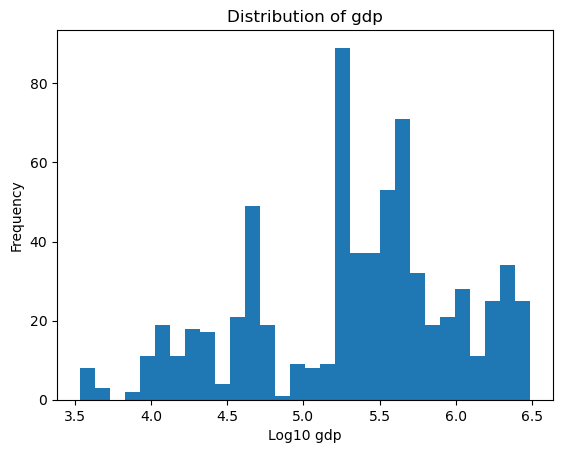

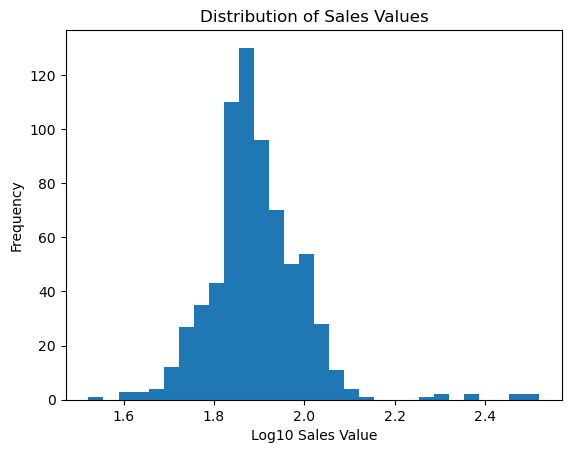

Skewness gdp_log: -0.456427583094306
Kurtosis gdp_log: -0.41871886161153915
Skewness sales_log: 1.3689001522770325
Kurtosis sales_log: 7.136530833878625


,count,mean,std,min,25%,50%,75%,max
year,691.0,2020.250362,2.817566,2016.000000,2018.000000,2020.000000,2023.000000,2.025000e+03
sales_value,691.0,80.820302,26.590064,33.300000,68.531250,76.220000,87.441667,3.309667e+02
gdp,691.0,555535.065557,734114.742565,3388.100000,55707.900000,279489.500000,579927.050000,3.094378e+06
gdp_log,691.0,5.338455,0.684574,3.529956,4.745917,5.446365,5.763373,6.490573e+00
sales_log,691.0,1.892571,0.106121,1.522444,1.835889,1.882069,1.941718,2.519784e+00


In [106]:
# log-transform GDP


df["gdp_log"] = np.log10(df["gdp"])
df["sales_log"] = np.log10(df["sales_value"])



plt.hist(df['gdp_log'], bins=30)
plt.title('Distribution of gdp')
plt.xlabel('Log10 gdp')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['sales_log'], bins=30)
plt.title('Distribution of Sales Values')
plt.xlabel('Log10 Sales Value')
plt.ylabel('Frequency')
plt.show()


print("Skewness gdp_log:", df["gdp_log"].skew())
print("Kurtosis gdp_log:", df["gdp_log"].kurtosis())

print("Skewness sales_log:", df["sales_log"].skew())
print("Kurtosis sales_log:", df["sales_log"].kurtosis())
df.describe().T

Log transformation reduces skewness and makes cross-country comparisons more meaningful by compressing extreme values.

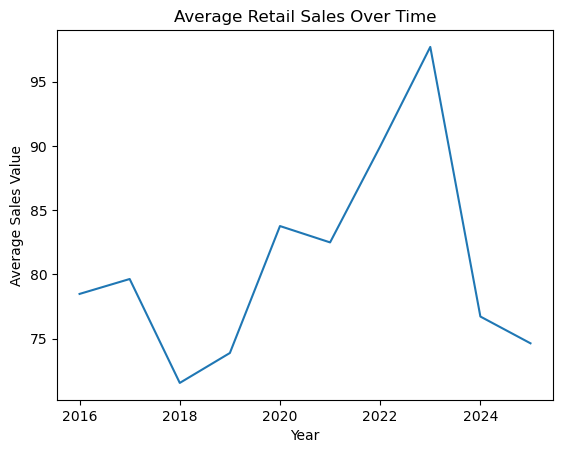

In [107]:
# retail sales over time
sales_over_time = df.groupby('year')['sales_value'].mean()
sales_over_time.plot()
plt.title('Average Retail Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Average Sales Value')
plt.show()

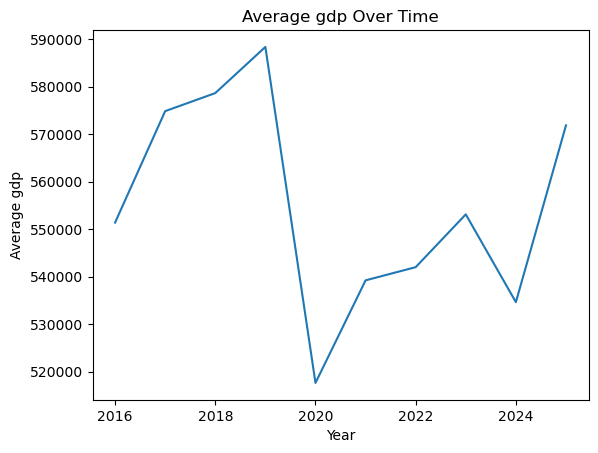

In [108]:
# gdp over time
gdp_over_time = df.groupby('year')['gdp'].mean()
gdp_over_time.plot()
plt.title('Average gdp Over Time')
plt.xlabel('Year')
plt.ylabel('Average gdp')
plt.show()


Growth rates are used because they capture changes over time rather than absolute economic size, making countries more comparable.

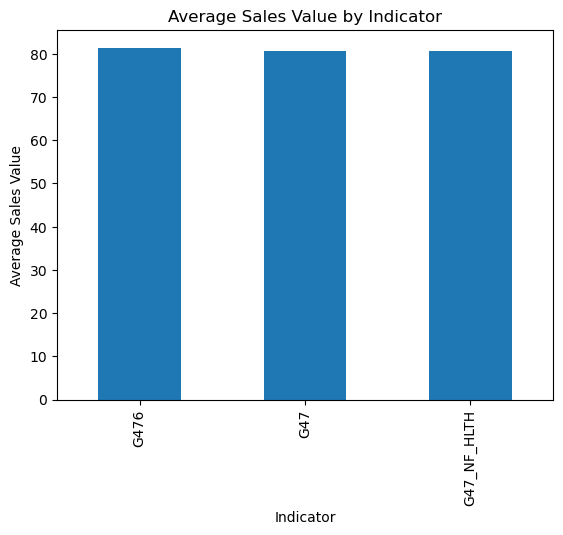

In [109]:
# ===========================
# Sector comparison
# ===========================

avg_sales = df.groupby('indicator')['sales_value'].mean().sort_values(ascending=False)
avg_sales.plot(kind='bar')
plt.title('Average Sales Value by Indicator')
plt.xlabel('Indicator')
plt.ylabel('Average Sales Value')
plt.show()

Sectoral differences are present but moderate, suggesting:
- Broadly similar scale across retail categories
- Differences emerge more in volatility than in level

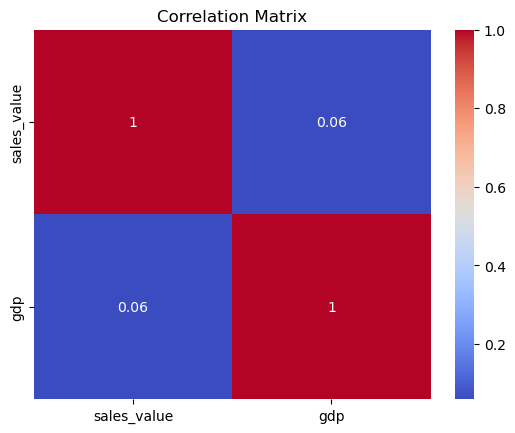

In [110]:
# ============================
# correlation analysis
# ============================

corr = df[['sales_value', 'gdp']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- GDP and sales show positive relationship
- Growth variables are more informative than levels
- Sector sensitivity to macro conditions varies

<Axes: xlabel='gdp_growth', ylabel='sales_growth'>

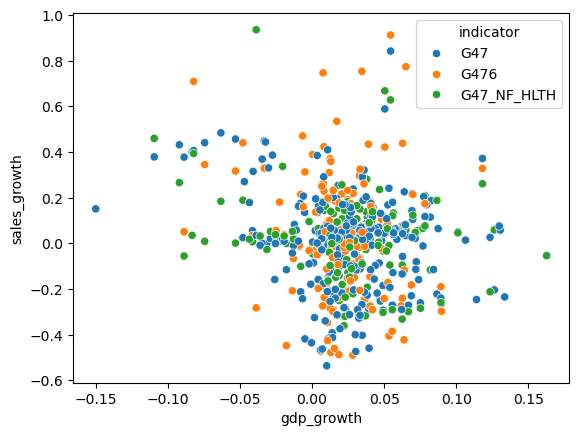

In [111]:
# ============================= 
# Feature engineering 
# ============================= 
df = df.sort_values(["country", "indicator", "year"]) 
df["sales_growth"] = df.groupby(["country", "indicator"])["sales_value"].pct_change() 
df["gdp_growth"] = df.groupby("country")["gdp"].pct_change() 
sns.scatterplot(x="gdp_growth", y="sales_growth", hue="indicator", data=df)

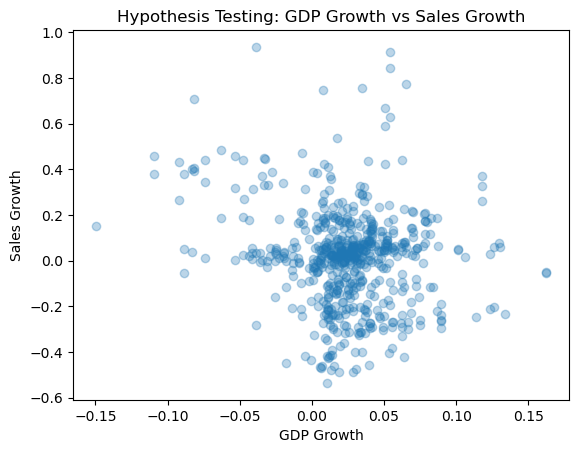

In [112]:
# ============================
# core hypothesis testing
# ============================

plt.scatter(df["gdp_growth"], df["sales_growth"], alpha=0.3)
plt.xlabel("GDP Growth")
plt.ylabel("Sales Growth")
plt.title("Hypothesis Testing: GDP Growth vs Sales Growth")
plt.show()

This scatter plot compares annual GDP growth with annual retail sales growth across countries and retail sectors. A strong relationship would appear as a clear upward trend. The observed dispersion suggests that GDP growth alone does not fully explain changes in retail sales. Differences between sector clusters indicate that some retail categories may respond differently to macroeconomic conditions, although additional statistical testing would be needed to quantify these relationships.

In [113]:
# lag analysis

df["gdp_lag1"] = df.groupby("country")["gdp"].shift(1)
print(df[["country", "year", "gdp", "gdp_lag1"]].head())


  country  year      gdp  gdp_lag1
0      AL  2016  10420.1       NaN
2      AL  2017  10762.2   10420.1
4      AL  2018  11157.3   10762.2
6      AL  2019  11387.4   11157.3
8      AL  2020  11010.1   11387.4


Conclusions
- Retail sales and GDP exhibit a positive overall relationship.
- Discretionary retail (G476) appears more volatile than essential retail categories.
- Essential retail (G47_NF_HLTH) remains comparatively stable across the study period.
- Relationships between GDP growth and retail sales growth appear relatively weak, suggesting that short-term macroeconomic fluctuations do not fully explain retail behaviour.
- Overall, the findings are consistent with, but do not prove, the lipstick effect hypothesis. Further statistical modelling would be required to establish causality.


- GDP and retail sales show an overall positive relationship.
- The discretionary retail sector (G476) exhibits greater variability than the essential retail sector (G47_NF_HLTH).
- Essential retail sales appear relatively stable across the study period.
- The relationship between GDP changes and retail sales is not immediate and may involve delayed responses, although further analysis would be needed to confirm lag effects.
- The findings are consistent with, but do not prove, the lipstick effect hypothesis.